<a href="https://colab.research.google.com/github/huseyinTozluyurt/Machine-Learning-Projects/blob/main/BeginnerProjects/SimpleClassification/SimpleClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Simple Classification

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [ ]:
fruits = pd.read_table('/content/drive/MyDrive/Colab Notebooks/UniversityMichigan/DATA/fruit_data_with_colors.txt')

In [ ]:
fruits.head(7)

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81


In [ ]:
# create a mapping from fruit label value to fruit name to make results easier to interpret
lookup_fruit_name = dict(zip(fruits.fruit_label.unique(), fruits.fruit_name.unique()))
lookup_fruit_name

{np.int64(1): 'apple',
 np.int64(2): 'mandarin',
 np.int64(3): 'orange',
 np.int64(4): 'lemon'}

## Examining Data

/tmp/ipykernel_1362/1886839401.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gnuplot')


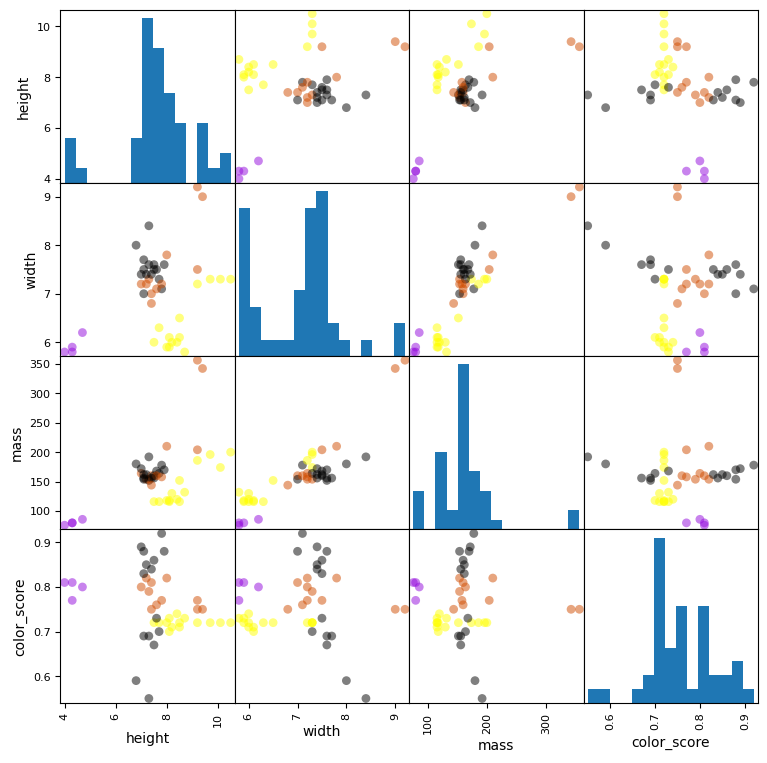

In [ ]:
# plotting a scatter matrix
from matplotlib import cm

X = fruits[['height', 'width', 'mass', 'color_score']]
y = fruits['fruit_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

cmap = cm.get_cmap('gnuplot')
scatter = pd.plotting.scatter_matrix(X_train, c= y_train, marker = 'o', s=40, hist_kwds={'bins':15}, figsize=(9,9), cmap=cmap)

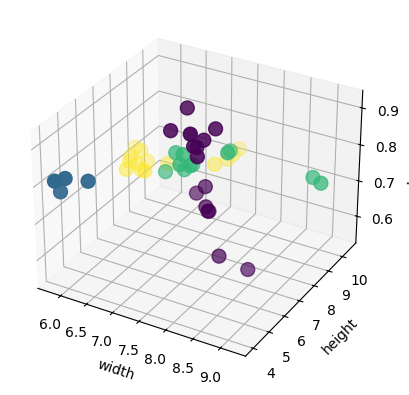

In [ ]:
# plotting a 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_train['width'], X_train['height'], X_train['color_score'], c = y_train, marker = 'o', s=100)
ax.set_xlabel('width')
ax.set_ylabel('height')
ax.set_zlabel('color_score')
plt.show()

## Model Training

In [ ]:
X = fruits[['mass','width','height']]
y = fruits['fruit_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
knn.score(X_test, y_test)

0.5333333333333333

In [ ]:
# first example: a small fruit with mass 20g, width 4.3 cm, height 5.5 cm
fruit_prediction = knn.predict([[20, 4.3, 5.5]])
lookup_fruit_name[fruit_prediction[0]]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'mandarin'

In [ ]:
# second example: a larger, elongated fruit with mass 100g, width 6.3 cm, height 8.5 cm
fruit_prediction = knn.predict([[100, 6.3, 8.5]])
lookup_fruit_name[fruit_prediction[0]]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'lemon'

### Visualizing KNN Decision Boundaries

Since `adspy_shared_utilities` is not available, here's a custom function `plot_decision_boundary_knn` that can visualize the decision boundaries of your trained K-Nearest Neighbors classifier for two selected features. It will keep any other features at their mean value from the training data to create a 2D projection of the decision space.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier


def plot_knn_decision_boundary(X_train, y_train, k=5):

    # Create KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Create a grid covering the feature space
    x_min = X_train.iloc[:, 0].min() - 1
    x_max = X_train.iloc[:, 0].max() + 1

    y_min = X_train.iloc[:, 1].min() - 1
    y_max = X_train.iloc[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    # Put grid points into a format KNN understands
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Predict the class for every point
    Z = knn.predict(grid_points)

    # Reshape predictions back into the grid
    Z = Z.reshape(xx.shape)

    # Colors for the four fruit classes
    cmap_background = ListedColormap([
        'lightcoral',
        'lightgreen',
        'mediumpurple',
        'lightgray'
    ])

    cmap_points = ListedColormap([
        'red',
        'lime',
        'blue',
        'gray'
    ])

    # Plot decision regions
    plt.figure(figsize=(10, 7))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.6,
        cmap=cmap_background
    )

    # Plot training samples
    scatter = plt.scatter(
        X_train.iloc[:, 0],
        X_train.iloc[:, 1],
        c=y_train,
        cmap=cmap_points,
        edgecolor='black',
        s=80
    )

    plt.xlabel(X_train.columns[0])
    plt.ylabel(X_train.columns[1])

    plt.title(
        f'KNN Decision Boundaries (k={k})'
    )

    plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


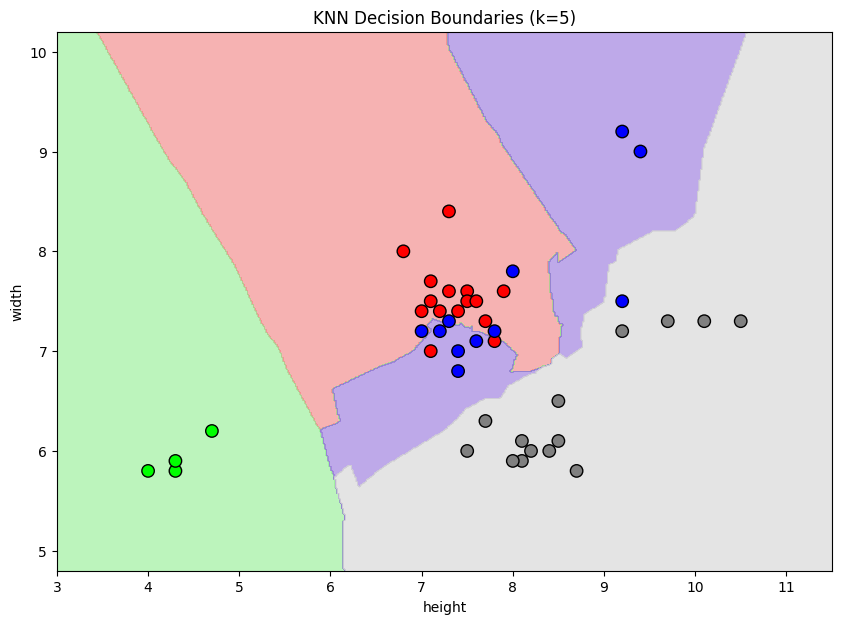

In [ ]:
X = fruits[['height', 'width']]
y = fruits['fruit_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=0
)

plot_knn_decision_boundary(
    X_train,
    y_train,
    k=5
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


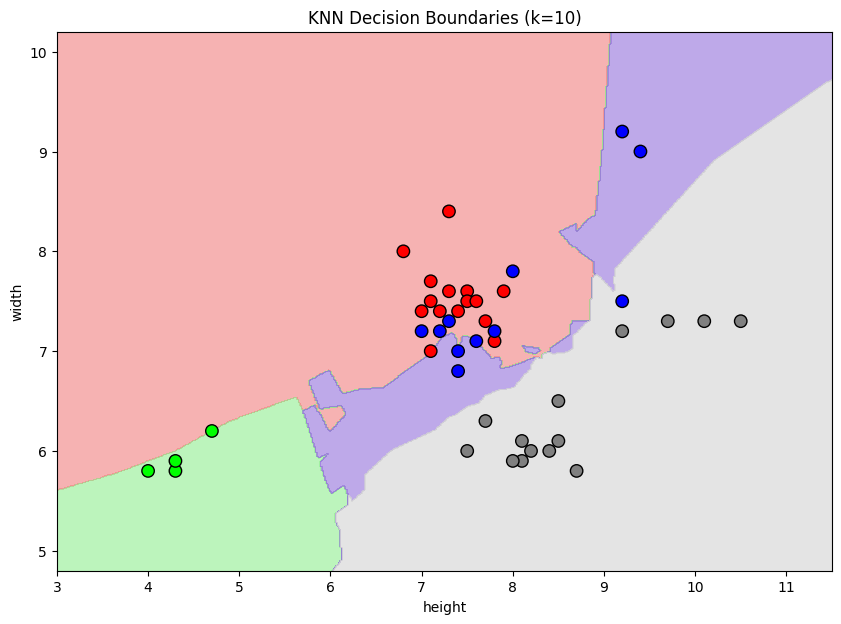

In [ ]:
plot_knn_decision_boundary(
    X_train,
    y_train,
    k=10
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


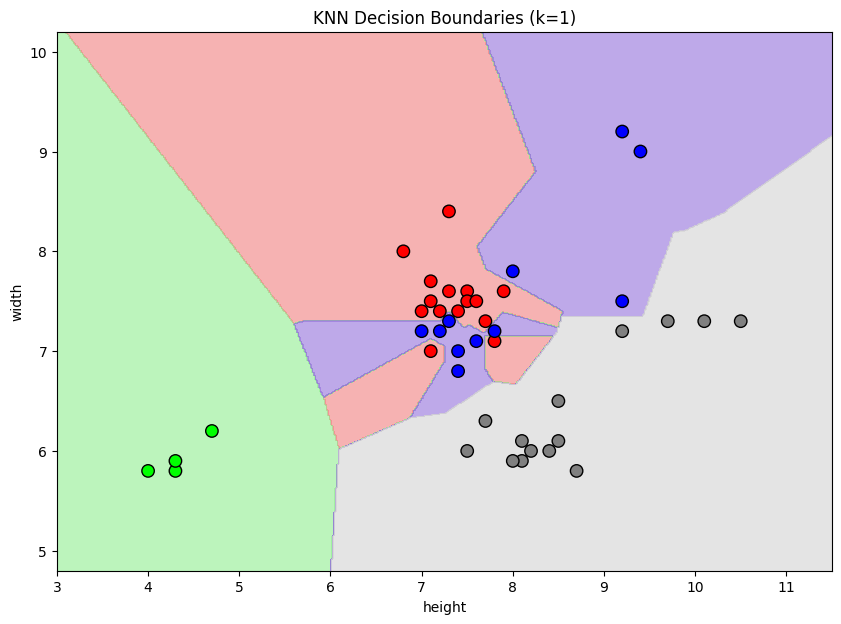

In [ ]:
plot_knn_decision_boundary(
    X_train,
    y_train,
    k=1
)

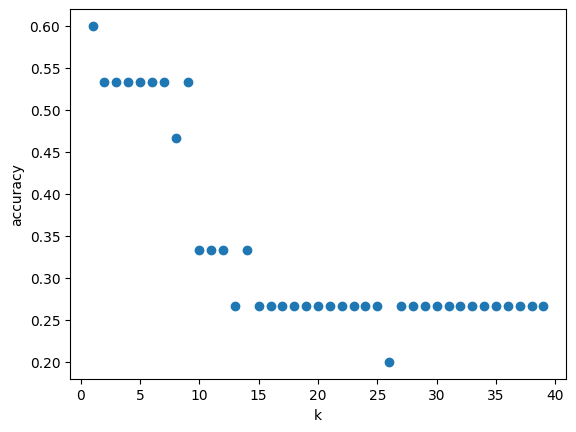

In [ ]:
k_range = range(1,40)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)
plt.xticks([0,5,10,15,20,25,30,35,40]);

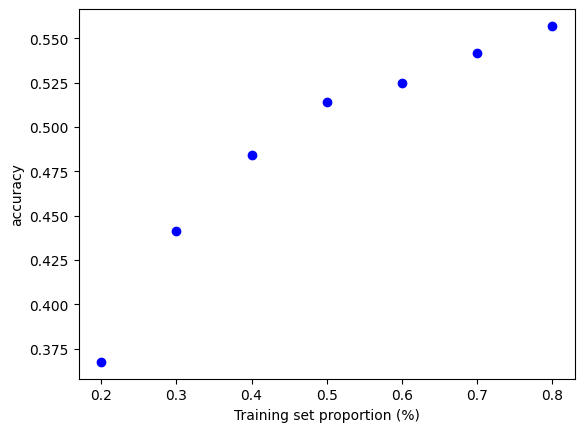

In [ ]:
t = [0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

knn = KNeighborsClassifier(n_neighbors = 5)

plt.figure()

for s in t:

    scores = []
    for i in range(1,1000):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1-s)
        knn.fit(X_train, y_train)
        scores.append(knn.score(X_test, y_test))
    plt.plot(s, np.mean(scores), 'bo')

plt.xlabel('Training set proportion (%)')
plt.ylabel('accuracy');